Cargando modelo YOLO...
Video: 1280x720 @ 30fps
Total frames: 9184

Procesando video...

Progreso: 3.3% - Frame 300/9184
Progreso: 3.3% - Frame 300/9184
Progreso: 6.5% - Frame 600/9184
Progreso: 6.5% - Frame 600/9184
Progreso: 9.8% - Frame 900/9184
Progreso: 9.8% - Frame 900/9184
Progreso: 13.1% - Frame 1200/9184
Progreso: 13.1% - Frame 1200/9184
Progreso: 16.3% - Frame 1500/9184
Progreso: 16.3% - Frame 1500/9184
Progreso: 19.6% - Frame 1800/9184
Progreso: 19.6% - Frame 1800/9184
Progreso: 22.9% - Frame 2100/9184
Progreso: 22.9% - Frame 2100/9184
Progreso: 26.1% - Frame 2400/9184
Progreso: 26.1% - Frame 2400/9184
Progreso: 29.4% - Frame 2700/9184
Progreso: 29.4% - Frame 2700/9184
Progreso: 32.7% - Frame 3000/9184
Progreso: 32.7% - Frame 3000/9184
Progreso: 35.9% - Frame 3300/9184
Progreso: 35.9% - Frame 3300/9184
Progreso: 39.2% - Frame 3600/9184
Progreso: 39.2% - Frame 3600/9184
Progreso: 42.5% - Frame 3900/9184
Progreso: 42.5% - Frame 3900/9184
Progreso: 45.7% - Frame 4200/9184
Progr

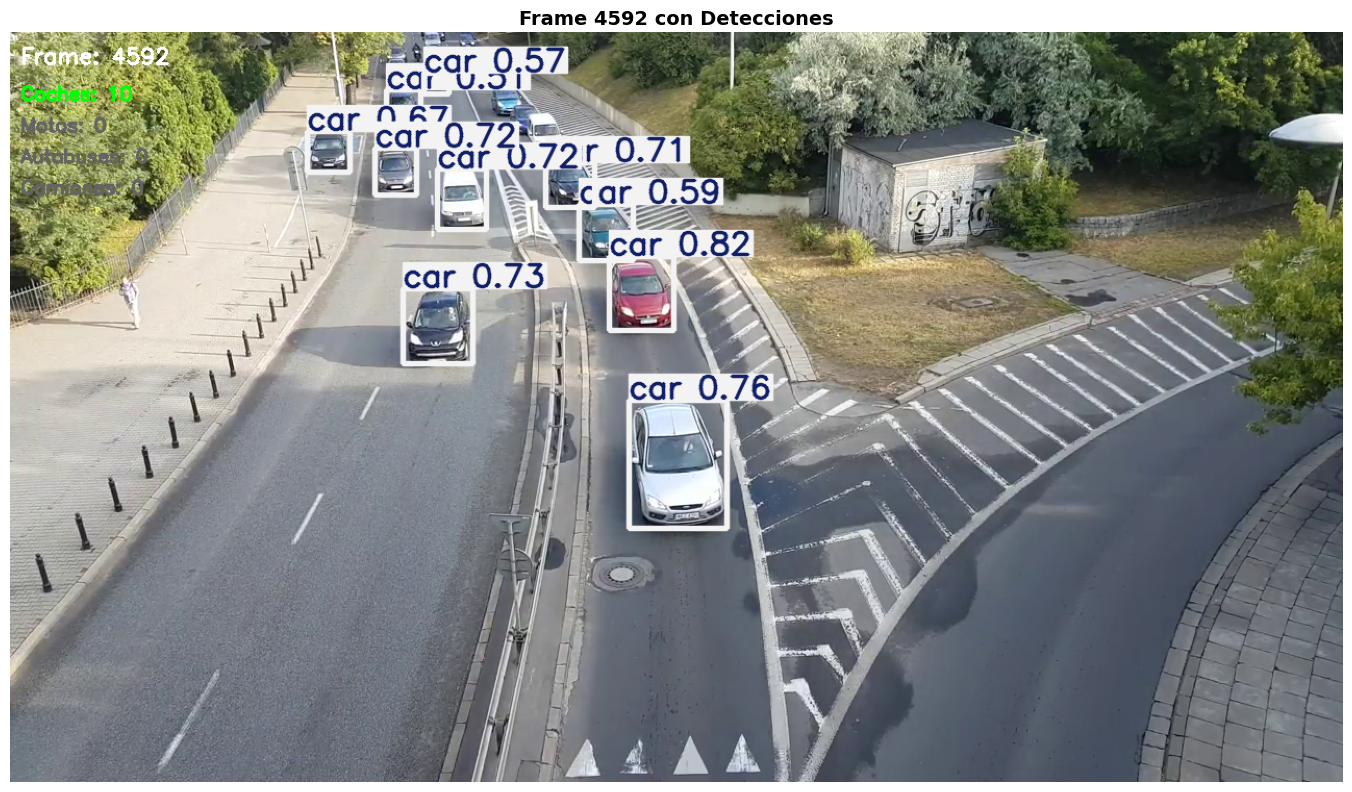


✅ Proceso completado con éxito


In [12]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Cargar modelo
print("Cargando modelo YOLO...")
model = YOLO("yolo11n.pt")

# Abrir video
cap = cv2.VideoCapture("video_trafico.mp4")
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {ancho}x{alto} @ {fps}fps")
print(f"Total frames: {total_frames}\n")

# Video de salida
writer = cv2.VideoWriter('trafficCam.mp4', 
                         cv2.VideoWriter_fourcc(*'mp4v'), 
                         fps, (ancho, alto))

# Contadores TOTALES (suma de todos los frames)
total_detecciones = {2: 0, 3: 0, 5: 0, 7: 0}
nombres = {2: 'Coches', 3: 'Motos', 5: 'Autobuses', 7: 'Camiones'}

# Frame de ejemplo
frame_ejemplo = None
frame_num = 0

print("Procesando video...\n")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_num += 1
    
    # Detectar vehículos
    results = model(frame, conf=0.5, classes=[2, 3, 5, 7], verbose=False)
    
    # Contar detecciones EN ESTE FRAME
    detecciones_frame = {2: 0, 3: 0, 5: 0, 7: 0}
    
    for box in results[0].boxes:
        clase = int(box.cls[0])
        detecciones_frame[clase] += 1      # Contador del frame
        total_detecciones[clase] += 1       # Contador total
    
    # Dibujar detecciones
    frame_anotado = results[0].plot()
    
    # AÑADIR TEXTO CON CONTEO EN EL FRAME
    y_pos = 30
    cv2.putText(frame_anotado, f"Frame: {frame_num}", 
                (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    y_pos += 35
    for clase in [2, 3, 5, 7]:
        texto = f"{nombres[clase]}: {detecciones_frame[clase]}"
        color = (0, 255, 0) if detecciones_frame[clase] > 0 else (100, 100, 100)
        cv2.putText(frame_anotado, texto, (10, y_pos), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        y_pos += 30
    
    # Guardar video
    writer.write(frame_anotado)
    
    # Guardar frame de ejemplo (mitad del video)
    if frame_num == total_frames // 2:
        frame_ejemplo = frame_anotado.copy()
    
    # Mostrar progreso
    if frame_num % 300 == 0:
        porcentaje = (frame_num / total_frames) * 100
        print(f"Progreso: {porcentaje:.1f}% - Frame {frame_num}/{total_frames}")

# Cerrar todo
cap.release()
writer.release()

# ===== RESULTADOS =====
print("\n" + "="*60)
print("RESULTADOS FINALES")
print("="*60)
print(f"\nFrames procesados: {frame_num}\n")

print("TOTAL DE DETECCIONES (suma de todos los frames):")
print("-"*60)
for clase in [2, 3, 5, 7]:
    count = total_detecciones[clase]
    promedio = count / frame_num if frame_num > 0 else 0
    print(f"  {nombres[clase]:12} : {count:5} detecciones ({promedio:.2f} por frame)")

print("-"*60)
print(f"  {'TOTAL':12} : {sum(total_detecciones.values()):5} detecciones")
print("="*60)

print(f"\n✅ Video guardado: trafficCam.mp4")

# Mostrar frame de ejemplo
if frame_ejemplo is not None:
    print("\n📸 Mostrando frame de ejemplo...\n")
    
    frame_rgb = cv2.cvtColor(frame_ejemplo, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.title(f'Frame {total_frames // 2} con Detecciones', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    plt.savefig('frame_ejemplo.png', dpi=150, bbox_inches='tight')
    print("✅ Imagen guardada: frame_ejemplo.png")
    plt.show()

print("\n✅ Proceso completado con éxito")

